---
numbering:
  enumerator: "15.%s"
  equation:
    template: "%s"  
---

(chap_backtest)=
# Portfolio backtesting

In this section, we introduce the notations and framework that will be used when analyzing and comparing investment strategies. Portfolio backtesting is often conceived and perceived as a quest to find the best strategy - or at least a solidly profitable one. When carried out thoroughly, this possibly long endeavor may entice the layman to confuse a fluke for a robust policy. Two papers published back-to-back warn against the **perils of data snooping**, which is related to $p$-hacking. In both cases, the researcher will torture the data until the sought result is found.

@fabozzi2018being acknowledge that only strategies that work make it to the public, while thousands (at least) have been tested. Picking the pleasing outlier (the only strategy that seemed to work) is likely to generate disappointment when switching to real trading. In a similar vein, @arnott2019backtesting provide a list of principles and safeguards that any analyst should follow to avoid any type of error when backtesting strategies. The worst type is arguably **false positives** whereby strategies are found (often by cherrypicking) to outperform in one very particular setting, but will likely fail in live implementation.

In addition to these recommendations on portfolio constructions, @arnott2019alice also warn against the hazards of blindly investing in smart beta products related to academic factors. Plainly, expectations should not be set too high or face the risk of being disappointed. Another takeaway from their article is that **economic cycles** have a strong impact on factor returns: correlations change quickly and drawdowns can be magnified in times of major downturns.

Backtesting is more complicated than it seems and it is easy to make small mistakes that lead to *apparently* good portfolio policies. This chapter lays out a rigorous approach to this exercise, discusses a few caveats, and proposes a lengthy example.

## Setting the protocol

We consider a dataset with three dimensions: time $t=1,\dots,T$, assets $n=1,\dots,N$ and characteristics $k=1,\dots,K$. One of these attributes must be the price of asset $n$ at time $t$, which we will denote $p_{t,n}$. From that, the computation of the arithmetic return is straightforward ($r_{t,n}=p_{t,n}/p_{t-1,n}-1$) and so is any heuristic measure of profitability. For simplicity, we assume that time points are equidistant or uniform, i.e., that $t$ is the index of a trading day or of a month for example. If each point in time $t$ has data available for all assets, then this makes a dataset with $I=T\times N$ rows.

The dataset is first split in two: the out-of-sample period and the **initial buffer** period. The buffer period is required to train the models for the first portfolio composition. This period is determined by the size of the training sample. There are two options for this size: fixed (usually equal to 2 to 10 years) and expanding. In the first case, the training sample will roll over time, taking into account only the most recent data. In the second case, models are built on all of the available data, the size of which increases with time. This last option can create problems because the first dates of the backtest are based on much smaller amounts of information compared to the last dates. Moreover, there is an ongoing debate on whether including the full history of returns and characteristics is advantageous or not. Proponents argue that this allows models to see many different **market conditions**. Opponents make the case that old data is by definition outdated and thus useless and possibly misleading because it won't reflect current or future short-term fluctuations.

Recent evidence supports the rolling choice. @audrino2024hard show that once the training window and how often the model is refit are properly tuned, a simple linear benchmark for volatility forecasting is hard to beat by machine learning models. The window choice matters more than model sophistication. @bloch2025false go further and connect short lookback windows to a statistical illusion. Because reliable estimation of the mean, variance and Sharpe ratio requires more data than short windows can offer, the apparent responsiveness of short window strategies is often just noise dressed up as signal.

Henceforth, we choose the rolling period option for the training sample, as depicted in the figure below.

```{figure} images/backtestoos.png
:name: fig-backtestoos
:align: center
Backtesting with rolling windows. The training set of the first period is simply the buffer period.
```

Two crucial design choices are the **rebalancing frequency** and the **horizon** at which the label is computed. It is not obvious that they should be equal but their choice should make sense. It can seem right to train on a 12-month forward label (which captures longer trends) and invest monthly or quarterly. However, it seems odd to do the opposite and train on short-term movements (monthly) and invest at a long horizon.

These choices have a direct impact on how the backtest is carried out. If we note:

- $\Delta_h$ for the holding period between 2 rebalancing dates (in days or months);
- $\Delta_s$ for the size of the desired training sample (in days or months - not taking the number of assets into consideration);
- $\Delta_l$ for the horizon at which the label is computed (in days or months),

then the total length of the training sample should be $\Delta_s+\Delta_l$. Indeed, at any moment $t$, the training sample should stop at $t-\Delta_l$ so that the last point corresponds to a label that is calculated until time $t$. This is highlighted in the figure below in the form of the red danger zone. We call it the red zone because any observation which has a time index $s$ inside the interval $(t-\Delta_l,t]$ will engender a forward looking bias. Indeed if a feature is indexed by $s \in (t-\Delta_l,t]$, then by definition, the label covers the period $[s,s+\Delta_l]$ with $s+\Delta_l>t$. At time $t$, this requires knowledge of the future and is naturally not realistic.

```{figure} images/backtestoos2.png
:name: fig-backtestoos2
:align: center
The subtleties in rolling training samples.
```

## Turning signals into portfolio weights

The predictive tools outlined in Chapters {ref}`chap_lasso` to {ref}`chap_ensemble` are only meant to provide a signal that is expected to give some information on the future profitability of assets. There are many ways that this signal can be integrated in an investment decision (see @snow2020machine for ways to integrate ML tools into this task). @guidolin2025machine provide a broader recent survey, covering systematic trading, weight optimization, smart beta, textual analysis and trade execution.

First and foremost, there are at least two steps in the portfolio construction process and the signal can be used at any of these stages. Relying on the signal for both steps puts a lot of emphasis on the predictions and should only be considered when the level of confidence in the forecasts is high.

The first step is **selection**. While a forecasting exercise can be carried out on a large number of assets, it is not compulsory to invest in all of these assets. In fact, for long-only portfolios, it would make sense to take advantage of the signal to exclude those assets that are presumably likely to underperform in the future. Often, portfolio policies have fixed sizes that impose a constant number of assets. One heuristic way to exploit the signal is to select the assets that have the most favorable predictions and to discard the others. This naive idea is often used in the asset pricing literature: portfolios are formed according to the quantiles of underlying characteristics and some characteristics are deemed interesting if the corresponding **sorted portfolios** exhibit very different profitabilities (e.g., high average return for high quantiles versus low average return for low quantiles).

This is for instance an efficient way to test the relevance of the signal. If $Q$ portfolios $q=1,\dots,Q$ are formed according to the rankings of the assets with respect to the signal, then one would expect that the out-of-sample performance of the portfolios be monotonic with $q$. While a rigorous test of monotonicity would require to account for all portfolios (see, e.g., @romano2013testing), it is often only assumed that the extreme portfolios suffice. If the difference between portfolio number 1 and portfolio number $Q$ is substantial, then the signal is valuable. Whenever the investor is able to short assets, this amounts to a dollar neutral strategy.

Selection based on simple quantile sorts can be improved. @poh2020building cast stock selection as a ranking problem and show that learning to rank algorithms, trained on pairwise or listwise comparisons rather than on a pointwise loss, roughly triple the Sharpe ratio of a cross sectional momentum strategy compared to standard regression based sorts. @feng2019deep push the sorting step itself into a deep network: firm characteristics are mapped into long short portfolio weights through a nonlinear activation trained to minimize pricing errors rather than forecast error, generalizing the usual characteristic sort. Combining several signals also matters. @muller2021interacting study every possible double sorted portfolio built from 102 anomalies and find that hundreds of interactions remain significant after correcting for the resulting multiple testing problem. @guidetti2025trust instead borrow a Majority Judgment ranking method from social choice theory to aggregate several anomalies into one portfolio, and show that this aggregation is more robust to the choice of rebalancing schedule and weighting scheme than simple z score or rank averaging.

The second step is **weighting**. If the selection process relied on the signal, then a simple weighting scheme is often a good idea. Equally weighted portfolios are known to be hard to beat (see @demiguel2007optimal), especially compared to their cap-weighted alternative, as is shown in @plyakha2014equal. More advanced schemes include equal risk contributions [@maillard2010properties] and constrained minimum variance [@coqueret2015diversified]. Both only rely on the covariance matrix of the assets and not on any proxy for the vector of expected returns.

For the sake of completeness, we explicitize a generalization of @coqueret2015diversified which is a generic constrained quadratic program:

$$
\underset{\textbf{w}}{\text{min}} \ \frac{\lambda}{2} \textbf{w}'\boldsymbol{\Sigma}\textbf{w}-\textbf{w}'\boldsymbol{\mu} , \quad \text{s.t.} \quad \begin{array}{ll} \textbf{w}'\textbf{1}=1, \\ (\textbf{w}-\textbf{w}_-)'\boldsymbol{\Lambda}(\textbf{w}-\textbf{w}_-) \le \delta_R,\\
\textbf{w}'\textbf{w} \le \delta_D,
\end{array}
$$ (eq:coq)

where it is easy to recognize the usual **mean-variance optimization** in the left-hand side. We impose three constraints on the right-hand side. The first one is the budget constraint (weights sum to one). The second one penalizes variations in weights (compared to the current allocation, $\textbf{w}_-$) via a diagonal matrix $\boldsymbol{\Lambda}$ that penalizes trading costs. This is a crucial point. Portfolios are rarely constructed from scratch and are most of the time **adjustments** from existing positions. In order to reduce the orders and the corresponding transaction costs, it is possible to penalize large variations from the existing portfolio. In the above program, the current weights are written $\textbf{w}_-$ and the desired ones $\textbf{w}$ so that $\textbf{w}-\textbf{w}_-$ is the vector of deviations from the current positions. The term $(\textbf{w}-\textbf{w}_-)'\boldsymbol{\Lambda}(\textbf{w}-\textbf{w}_-)$ is an expression that characterizes the sum of squared deviations, weighted by the diagonal coefficients $\Lambda_{n,n}$. This can be helpful because some assets may be more costly to trade due to liquidity (large cap stocks are more liquid and their trading costs are lower). When $\delta_R$ decreases, the rotation is reduced because weights are not allowed too deviate too much from $\textbf{w}_-$. The last constraint enforces **diversification** via the Herfindhal-Hirschmann index of the portfolio: the smaller $\delta_D$, the more diversified the portfolio.

Recalling that there are $N$ assets in the universe, the Lagrange form of {eq}`eq:coq` is:

$$
L(\textbf{w})= \frac{\lambda}{2} \textbf{w}'\boldsymbol{\Sigma}\textbf{w}-\textbf{w}'\boldsymbol{\mu}-\eta (\textbf{w}'\textbf{1}_N-1)+\kappa_R ( (\textbf{w}-\textbf{w}_-)'\boldsymbol{\Lambda}(\textbf{w}-\textbf{w}_-) - \delta_R)+\kappa_D(\textbf{w}'\textbf{w}-\delta_D),
$$ (eq:lagrangew)

and the first order condition

$$\frac{\partial}{\partial \textbf{w}}L(\textbf{w})= \lambda \boldsymbol{\Sigma}\textbf{w}-\boldsymbol{\mu}-\eta\textbf{1}_N+2\kappa_R \boldsymbol{\Lambda}(\textbf{w}-\textbf{w}_-)+2\kappa_D\textbf{w}=0,$$

yields

$$
\textbf{w}^*_\kappa=  (\lambda \boldsymbol{\Sigma}+2\kappa_R \boldsymbol{\Lambda} +2\kappa_D\textbf{I}_N)^{-1} \left(\boldsymbol{\mu} + \eta_{\lambda,\kappa_R,\kappa_D} \textbf{1}_N+2\kappa_R \boldsymbol{\Lambda}\textbf{w}_-\right),
$$ (eq:coqw)

with

$$\eta_{\lambda,\kappa_R,\kappa_D}=\frac{1- \textbf{1}_N'(\lambda\boldsymbol{\Sigma}+2\kappa_R \boldsymbol{\Lambda}+2\kappa_D\textbf{I}_N)^{-1}(\boldsymbol{\mu}+2\kappa_R\boldsymbol{\Lambda}\textbf{w}_-)}{\textbf{1}'_N(\lambda \boldsymbol{\Sigma}+2\kappa_R \boldsymbol{\Lambda}+2\kappa_D\textbf{I}_N)^{-1}\textbf{1}_N}.$$

This parameter ensures that the budget constraint is satisfied. The optimal weights in {eq}`eq:coqw` depend on three tuning parameters: $\lambda$, $\kappa_R$ and $\kappa_D$.

- When $\lambda$ is large, the focus is set more on risk reduction than on profit maximization (which is often a good idea given that risk is easier to predict);
- When $\kappa_R$ is large, the importance of transaction costs in {eq}`eq:lagrangew` is high and thus, in the limit when $\kappa_R \rightarrow \infty$, the optimal weights are equal to the old ones $\textbf{w}_-$ (for finite values of the other parameters).
- When $\kappa_D$ is large, the portfolio is more diversified and (all other things equal) when $\kappa_D \rightarrow \infty$, the weights are all equal (to $1/N$).
- When $\kappa_R=\kappa_D=0$, we recover the classical mean-variance weights which are a mix between the maximum Sharpe ratio portfolio proportional to $(\boldsymbol{\Sigma})^{-1} \boldsymbol{\mu}$ and the minimum variance portfolio proportional to $(\boldsymbol{\Sigma})^{-1} \textbf{1}_N$.

This seemingly complex formula is in fact very flexible and tractable. It requires some tests and adjustments before finding realistic values for $\lambda$, $\kappa_R$ and $\kappa_D$ (see exercise at the end of the chapter). In @pedersen2020enhanced, the authors recommend a similar form, except that the covariance matrix is shrunk towards the diagonal matrix of sample variances and the expected returns are mix between a signal and an anchor portfolio. The authors argue that their general formulation has links with robust optimization (see also @kim2014deciphering), Bayesian inference [@lai2011mean], matrix denoising via random matrix theory, and, naturally, **shrinkage**. In fact, shrunk expected returns have been around for quite some time (@jorion1985international, @kan2007optimal and @bodnar2013equivalence) and simply seek to diversify and reduce estimation risk.

An older and simpler alternative to the quadratic program above is the parametric portfolio policy of @brandt2009parametric, which maps characteristics directly into weights through a small parameter vector and sidesteps the need to model returns explicitly. @connor2021dynamic extend this idea into a two step semiparametric model where a first stage builds factor mimicking sub portfolios and a second stage combines them dynamically using expected utility. Recent work corrects a blind spot of the original policy: it treats the estimated parameter as if it were the truth and so ignores policy risk. @herculano2026bayesian and @lamoureux2026gibbs both place a Bayesian prior on the policy coefficients, using two different generalized Bayesian formulations, and find sizably higher Sharpe ratios, lower turnover and lower tail risk once this estimation risk is accounted for, especially during crises. @simon2025deep instead replace the linear policy with a deep network and show that risk aversion acts as a natural regularizer that keeps the added complexity in check.

A more direct route skips the return forecast altogether and learns portfolio weights straight from characteristics. @bell2026alphaglass propose an interpretable model that maps characteristics into additive signals with sparse interactions and converts them into long short weights through a differentiable rank and mask layer, optimizing the Sharpe ratio end to end while keeping the drivers of each position traceable. @you2025markowitz and @wang2026machine pursue a similar end to end philosophy from different angles: the first turns the whole mean variance program into an unconstrained learning task, while the second lets each investor's own risk preferences and constraints shape the prediction stage rather than being added afterward. @coulombe2023maximally take yet another direction and optimize weights so that the resulting portfolio return is maximally predictable in itself, combining a random forest and a constrained ridge regression to extend earlier maximally predictable portfolio approaches based on linear factors. Finally, since all of these approaches still need an estimate of expected returns, @asimit2025distribution propose a distribution free shrinkage estimator of the mean vector that improves both return prediction and mean variance portfolios in high dimension.


## Performance metrics

The evaluation of performance is a key stage in a backtest. This section, while not exhaustive, is intended to cover the most important facets of portfolio assessment.

### Discussion

While the evaluation of the accuracy of ML tools (See {ref}`sec_mlmetrics`) is of course valuable (and imperative!), the portfolio returns are the ultimate yardstick during a backtest. One essential element in such an exercise is a **benchmark** because raw and absolute metrics don't mean much on their own.

This is not only true at the portfolio level, but also at the ML engine level. In most of the trials of the previous chapters, the MSE of the models on the testing set revolves around 0.037. An interesting figure is the variance of one-month returns on this set, which corresponds to the error made by a constant prediction of 0 all the time. This benchmark is the one used in the out-of-sample $R^2$ of @gu2018empirical.

This gap between statistical accuracy and portfolio performance is not a minor detail. @salcher2026lost show that MSE based measures of forecast accuracy can be weakly or even negatively correlated with the Sharpe ratio of the resulting portfolio. They propose a risk adjusted forecast error measure built on the Mahalanobis distance, which weights forecast errors by the inverse covariance of returns and thus penalizes mistakes on exactly the low risk, high return looking positions that mean variance optimization tends to overweight. Their simulations and empirical application confirm that this measure tracks the Sharpe ratio gap far better than plain RMSE.

In portfolio choice, the most elementary allocation is the uniform one, whereby each asset receives the same weight. This seemingly simplistic solution is in fact an incredible benchmark, one that is hard to beat consistently (see @demiguel2007optimal and @plyakha2014equal). Theoretically, uniform portfolios are optimal when uncertainty, ambiguity or estimation risk is high (@pflug20121, @maillet2015global, @zhao2021efficient) and empirically, it cannot be outperformed even at the factor level [@dichtl2020build]. Below, we will pick an **equally weighted** (EW) portfolio of all stocks as our benchmark.

### Pure performance and risk indicators

We then turn to the definition of the usual metrics used both by practitioners and academics alike. Henceforth, we write $r^P=(r_t^P)_{1\le t\le T}$ and $r^B=(r_t^B)_{1\le t\le T}$ for the returns of the portfolio and those of the benchmark, respectively. When referring to some generic returns, we simply write $r_t$. There are many ways to analyze them and most of them rely on their distribution.

The simplest indicator is the average return:

$$\bar{r}_P=\mu_P=\mathbb{E}[r^P]\approx \frac{1}{T}\sum_{t=1}^T r_t^P, \quad \bar{r}_B=\mu_B=\mathbb{E}[r^B]\approx \frac{1}{T}\sum_{t=1}^T r_t^B,$$

where, obviously, the portfolio is noteworthy if $\mathbb{E}[r^P]>\mathbb{E}[r^B]$. Note that we use the arithmetic average above but the geometric one is also an option, in which case:

$$\tilde{\mu}_P\approx \left(\prod_{t=1}^T(1+r^P_t) \right)^{1/T}-1 , \quad \tilde{\mu}_B \approx  \left(\prod_{t=1}^T(1+r^B_t) \right)^{1/T}-1.$$

The benefit of this second definition is that it takes the compounding of returns into account and hence compensates for volatility pumping. To see this, consider a very simple two-period model with returns $-r$ and $+r$. The arithmetic average is zero, but the geometric one $\sqrt{1-r^2}-1$ is negative.

Akin to accuracy, it ratios evaluate the proportion of times when the position is in the right direction (long when the realized return is positive and short when it is negative). Hence hit ratios evaluate the propensity to make *good guesses*. This can be computed at the asset level (the proportion of positions in the correct direction) or at the portfolio level. In all cases, the computation can be performed on raw returns or on relative returns (e.g., compared to a benchmark). A meaningful hit ratio is the proportion of times that a strategy beats its benchmark. This is of course not sufficient, as many small gains can be offset by a few large losses.

Pure performance measures are almost always accompanied by **risk measures**. The second moment of returns is usually used to quantify the magnitude of fluctuations of the portfolio. A large variance implies sizable movements in returns, and hence in portfolio values. This is why the standard deviation of returns is called the **volatility** of the portfolio.

$$\sigma^2_P=\mathbb{V}[r^P]\approx \frac{1}{T-1}\sum_{t=1}^T (r_t^P-\mu_P)^2, \quad \sigma^2_B=\mathbb{V}[r^B]\approx \frac{1}{T-1}\sum_{t=1}^T (r_t^B-\mu_B)^2.$$

In this case, the portfolio can be preferred if it is less risky compared to the benchmark, i.e., when $\sigma_P^2<\sigma_B^2$ and when average returns are equal (or comparable).

Higher order moments of returns are sometimes used (skewness and kurtosis), but they are far less common. We refer for instance to @harvey2010portfolio for one method that takes them into account in the portfolio construction process.

For some people, the volatility is an incomplete measure of risk. It can be argued that it should be decomposed into 'good' volatility (when prices go up) versus 'bad' volatility when they go down. The downward semi-variance is computed as the variance taken over the negative returns:

$$\sigma^2_-\approx \frac{1}{\text{card}(r_t<0)}\sum_{t=1}^T (r_t-\mu_P)^21_{\{r_t<0\}}.$$

The average return and the volatility are the typical moment-based metrics used by practitioners. Other indicators rely on different aspects of the distribution of returns with a focus on tails and extreme events. The **Value-at-Risk** (VaR) is one such example. If $F_r$ is the empirical cdf of returns, the VaR at a level of confidence $\alpha$ (often taken to be 95%) is

$$\text{VaR}_\alpha(\textbf{r}_t)=F_r(1-\alpha).$$

It is equal to the realization of a bad scenario (of return) that is expected to happen $(1-\alpha)$% of the time on average.
An even more conservative measure is the so-called **Conditional Value at Risk** (CVaR), also known as expected shortfall, which computes the average loss of the worst ($1-\alpha$)% scenarios. Its empirical evaluation is

$$\text{CVaR}_\alpha(\textbf{r}_t)=\frac{1}{\text{Card}(r_t < \text{VaR}_\alpha(\text{r}_t))}\sum_{r_t < \text{VaR}_\alpha(\text{r}_t)}r_t.$$

Going crescendo in the severity of risk measures, the ultimate evaluation of loss is the **maximum drawdown**. It is equal to the maximum loss suffered from the peak value of the strategy. If we write $P_t$ for the time-$t$ value of a portfolio, the drawdown is

$$D_T^P=\underset{0 \le t \le T}{\text{max}} P_t-P_T ,$$

and the maximum drawdown is

$$MD_T^P=\underset{0 \le s \le T}{\text{max}} \left(\underset{0 \le t \le s}{\text{max}} P_t-P_s, 0\right) .$$

This quantity evaluates the greatest loss over the time frame $[0,T]$ and is thus the most conservative risk measure of all.

### Factor-based evaluation

In the spirit of factor models, performance can also be assessed through the lens of exposures. If we recall the original formulation from Equation {eq}`eq:apt`:

$$r_{t,n}= \alpha_n+\sum_{k=1}^K\beta_{t,k,n}f_{t,k}+\epsilon_{t,n}, $$

then the estimated $\hat{\alpha}_n$ is the performance that cannot be explained by the other factors. When returns are *excess* returns (over the risk-free rate) and when there is only one factor, the market factor, then this quantity is called Jensen's alpha [@jensen1968performance]. Often, it is simply referred to as *alpha*. The other estimate, $\hat{\beta}_{t,M,n}$ ($M$ for market), is the market beta.

Because of the rise of factor investing, it has become customary to also report the alpha of more exhaustive regressions. Adding the size and value premium (as in @fama1993common) and even momentum [@carhart1997persistence] helps understand if a strategy generates value beyond that which can be obtained through the usual factors.

### Risk-adjusted measures

Now, the tradeoff between the average return and the volatility is a cornerstone in modern finance, since @markowitz1952portfolio. The simplest way to synthesize both metrics is via the **information ratio**:

$$IR(P,B)=\frac{\mu_{P-B}}{\sigma_{P-B}},$$

where the index $P-B$ implies that the mean and standard deviations are computed on the long-short portfolio with returns $r_t^P-r_t^B$. The denominator $\sigma_{P-B}$ is sometimes called the **tracking error**.

The most widespread information ratio is the **Sharpe ratio** [@sharpe1966mutual] for which the benchmark is some riskless asset. Instead of directly computing the information ratio between two portfolios or strategies, it is often customary to compare their Sharpe ratios. Simple comparisons can benefit from statistical tests (see, e.g., @ledoit2008robust).

More extreme risk measures can serve as denominator in risk-adjusted indicators. The Managed Account Report (MAR) ratio is, for example, computed as

$$MAR^P = \frac{\tilde{\mu}_P}{MD^P},$$

while the Treynor ratio is equal to

$$\text{Treynor}=\frac{\mu_P}{\hat{\beta}_M},$$

i.e., the (excess) return divided by the market beta (see @treynor1965rate). This definition was generalized to multifactor expositions by @hubner2005generalized into the generalized Treynor ratio:

$$\text{GT}=\mu_P\frac{\sum_{k=1}^K\bar{f}_k}{\sum_{k=1}^K\hat{\beta}_k\bar{f}_k},$$

where the $\bar{f}_k$ are the sample average of the factors $f_{t,k}$. We refer to the original article for a detailed account of the analytical properties of this ratio.

### Transaction costs and turnover

Updating portfolio composition is not free. In all generality, the total cost of one rebalancing at time $t$ is proportional to $C_t=\sum_{n=1}^N | \Delta w_{t,n}|c_{t,n}$, where $\Delta w_{t,n}$ is the change in position for asset $n$ and $c_{t,n}$ the corresponding fee. This last quantity is often hard to predict, thus it is customary to use a proxy that depends for instance on market capitalization (large stocks have more liquid shares and thus require smaller fees) or bid-ask spreads (smaller spreads mean smaller fees).

As a first order approximation, it is often useful to compute the average turnover:

$$\text{Turnover}=\frac{1}{T-1}\sum_{t=2}^T\sum_{n=1}^N|w_{t,n}-w_{t-,n}|,$$

where $w_{t,n}$ are the desired $t$-time weights in the portfolio and $w_{t-,n}$ are the weights just before the rebalancing. The positions of the first period (launching weights) are exluded from the computation by convention. Transaction costs can then be proxied as a multiple of turnover (times some average or median cost in the cross-section of firms). This is a first order estimate of realized costs that does not take into consideration the evolution of the scale of the portfolio. Nonetheless, a rough figure is much better than none at all.

Once transaction costs (TCs) have been annualized, they can be deducted from average returns to yield a more realistic picture of profitability. In the same vein, the transaction cost-adjusted Sharpe ratio of a portfolio $P$ is given by

$$
SR_{TC}=\frac{\mu_P-TC}{\sigma_P}.
$$ (eq:SRTC)

Transaction costs are often overlooked in academic articles but can have a sizable impact in real life trading (see, e.g., @novy2015taxonomy). @martin2018transaction show how to use factor investing (and exposures) to combine and offset positions and reduce overall fees.

Two recent papers add further caution here. @yin2026implementation run fifteen benchmark strategies through five independent backtesting engines and show that, once nonzero transaction costs enter the picture, the choice of engine alone can move total returns by several percentage points for high turnover strategies, driven largely by undocumented differences in how each engine applies cost models. @beckmeyer2026reviving turn this around into a constructive framework: by combining machine learning return forecasts with scale dependent transaction cost estimates, they identify which anomalies remain profitable net of costs for funds of a given size, and show that a simple equally weighted basket of these implementable anomalies still delivers Sharpe ratios between 0.64 and 1.01.

## Common errors and issues

### Forward looking data

One of the most common mistakes in portfolio backtesting is the use of forward looking data. It is for instance easy to fall in the trap of the danger zone depicted in [](#fig-backtestoos2). In this case, the labels used at time $t$ are computed with knowledge of what happens at times $t+1$, $t+2$, etc. It is worth triple checking every step in the code to make sure that strategies are not built on prescient data.

(backov)=
### Backtest overfitting

The second major problem is backtest overfitting. The analogy with training set overfitting is easy to grasp. It is a well-known issue and was formalized for instance in @white2000reality and @romano2005stepwise. In portfolio choice, we refer to @bajgrowicz2012technical, @bailey2014deflated and @lopez2020false, and the references therein.

At any given moment, a backtest depends on *only* one particular dataset. Often, the result of the first backtest will not be satisfactory - for many possible reasons. Hence, it is tempting to have another try, when altering some parameters that were probably not optimal. This second test may be better, but not quite good enough - yet. Thus, in a third trial, a new weighting scheme can be tested, along with a new forecasting engine (more sophisticated). Iteratively, the backtester can only end up with a strategy that performs well enough, it is just a matter of time and trials.

One consequence of backtest overfitting is that it is illusory to hope for the same Sharpe ratios in live trading as those obtained in the backtest. Reasonable professionals divide the Sharpe ratio by two at least (@harvey2015backtesting, @suhonen2017quantifying). In @bailey2014deflated, the authors even propose a statistical test for Sharpe ratios, provided that some metrics of all tested strategies are stored in memory. The formula for deflated Sharpe ratios is:

$$
t = \phi\left((SR-SR^*)\sqrt{\frac{T-1}{1-\gamma_3SR+\frac{\gamma_4-1}{4}SR^2}} \right),
$$ (eq:tSR)

where $SR$ is the Sharpe Ratio obtained by the best strategy among all that were tested, and

$$SR^*=\mathbb{E}[SR]+\sqrt{\mathbb{V}[SR]}\left((1-\gamma)\phi^{-1}\left(1-\frac{1}{N}\right)+\gamma \phi^{-1}\left(1-\frac{1}{Ne}\right)  \right),$$

is the theoretical average maximum SR. Moreover,

- $T$ is the number of trading dates;
- $\gamma_3$ and $\gamma_4$ are the $skewness$ and $kurtosis$ of the returns of the chosen (best) strategy;
- $\phi$ is the cdf of the standard Gaussian law and $\gamma\approx 0,577$ is the Euler-Mascheroni constant;
- $N$ refers to the number of strategy trials.

If $t$ defined above is below a certain threshold (e.g., 0.95), then the $SR$ cannot be deemed significant: **the best strategy is not outstanding** compared to all of those that were tested. Most of the time, sadly, that is the case. In Equation {eq}`eq:tSR`, the realized SR must be above the theoretical maximum $SR^*$ and the scaling factor must be sufficiently large to push the argument inside $\phi$ close enough to two, so that $t$ surpasses 0.95.

Two recent papers quantify backtest fragility from angles that complement the deflated Sharpe ratio above. @chen2025design fit more than a thousand machine learning models that only differ in seemingly minor design choices, such as the target variable, the training window or how predictions are post processed, and find that the resulting spread in portfolio returns, what they call the nonstandard error, exceeds the usual standard error by 59%. @paskaramoorthy2025bias tackle a different source of fragility: resampling returns as if they were independent and identically distributed, a common fix for short backtests, disrupts the autocorrelation structure of returns and biases the Sharpe ratio of rolling window mean variance portfolios. They show the bias is often a modest fraction of ordinary estimation noise, but derive simple bounds, based on first lag autocorrelation, to help flag when it is not.

In the scientific community, test overfitting is also known as *p*-hacking. It is rather common in financial economics and the reading of @harvey2017presidential is strongly advised to grasp the magnitude of the phenomenon. *p*-hacking is also present in most fields that use statistical tests (see, e.g., @head2015extent to cite but one reference). There are several ways to cope with *p*-hacking:

1. don't rely on *p*-values [@amrhein2019scientists];
2. use detection tools [@elliott2019detecting];
3. or, finally, use advanced methods that process arrays of statistics (e.g., the Bayesianized versions of *p*-values to include some prior assessment from @harvey2017presidential, or other tests such as those proposed in @romano2005stepwise and @simonsohn2014p).

The first option is wise, but the drawback is that the decision process is then left to another arbitrary yardstick.

### Simple safeguards

As is mentioned at the beginning of the chapter, two common sense references for backtesting are @fabozzi2018being and @arnott2019backtesting. The pieces of advice provided in these two articles are often judicious and thoughtful.

One additional comment pertains to the output of the backtest. One simple, intuitive and widespread metric is the transaction cost-adjusted Sharpe ratio defined in Equation {eq}`eq:SRTC`. In the backtest, let us call $SR_{TC}^B$ the corresponding value for the benchmark, which we like to define as the equally-weighted portfolio of all assets in the trading universe (in our dataset, roughly one thousand US equities). If the $SR_{TC}^P$ of the best strategy is above $2\times SR_{TC}^B$, then there is probably a glitch somewhere in the backtest.

This criterion holds under two assumptions:

1) a sufficiently long enough out-of-sample period and
2) long-only portfolios.

It is unlikely that any realistic strategy can outperform a solid benchmark by a very wide margin over the long term. Being able to improve the benchmark's annualized return by 150 basis points (with comparable volatility) is already a great achievement. Backtests that deliver returns more than 5% above those of the benchmark are dubious.

## Implication of non-stationarity: forecasting is hard

This subsection is split into two parts: in the first, we discuss the reason that makes forecasting such a difficult task and in the second we present an important theoretical result originally developed towards machine learning but that sheds light on any discipline confronted with out-of-sample tests. An interesting contribution related to this topic is the study from @farmer2019pockets. The authors assess the predictive fit of linear models through time: they show that the fit is strongly varying: sometimes the model performs very well, sometimes, not so much. There is no reason why this should not be the case for ML algorithms as well.

### General comments

The careful reader must have noticed that throughout Chapters {ref}`chap_lasso` to {ref}`chap_ensemble`, the performance of ML engines is underwhelming. These disappointing results are there on purpose and highlight the crucial truth that machine learning is no panacea, no magic wand, no philosopher's stone that can transform data into golden predictions. Most ML-based forecasts fail. This is in fact not only true for very enhanced and sophisticated techniques, but also for simpler econometric approaches [@dichtl2019data], which again underlines the need to replicate results to challenge their validity.

One reason for that is that datasets are full of noise and extracting the slightest amount of signal is a tough challenge (we recommend a careful reading of the introduction of @timmermann2018forecasting for more details on this topic). One rationale for that is the ever time-varying nature of factor analysis in the equity space. Some factors can perform very well during one year and then poorly the next year and these reversals can be costly in the context of fully automated data-based allocation processes.

In fact, this is one major difference with many fields for which ML has made huge advances. In image recognition, numbers will always have the same shape, and so will cats, buses, etc. Likewise, a verb will always be a verb and syntaxes in languages do not change. This invariance, though sometimes hard to grasp, is nonetheless key to the great improvement both in computer vision and natural language processing.

In factor investing, there does not seem to be such invariance (see @cornell2020stock). There is no factor and no (possibly nonlinear) combination of factors that can explain and accurately forecast returns over long periods of several decades. The academic literature has yet to find such a model; but even if it did, a simple arbitrage reasoning would logically invalidate its conclusions in future datasets.

Two recent papers reinforce this message with direct evidence. @esakia2025what decompose the gains from machine learning factor models into a richer information set and a more flexible functional form, and show that once microcaps are excluded, transaction costs are imposed and short selling is restricted, the benefit of nonlinearity nearly disappears while the benefit of richer information persists only partially. @lu2025machine push further and show that a simple economically motivated arbitrage strategy can replicate most of the apparent alpha of neural network based long short portfolios, once unpublished anomalies and microcap stocks are excluded. What looks like a black box uncovering hidden patterns is often, on closer inspection, an old and well understood economic mechanism wearing a new coat.

### The no free lunch theorem

We start by underlying that the no free lunch theorem in machine learning has nothing to do with the asset pricing condition with the same name (see, e.g., @delbaen1994general, or, more recently, @cuchiero2016new). The original formulation was given by @wolpert1992connection but we also recommend a look at the more recent reference @ho2002simple. There are in fact several theorems and two of them can be found in @wolpert1997no.

The statement of the theorem is very abstract and requires some notational conventions. We assume that any training sample $S=(\{\textbf{x}_1,y_1\}, \dots, \{\textbf{x}_I,y_I\})$ is such that there exists an oracle function $f$ that perfectly maps the features to the labels: $y_i=f(\textbf{x}_i)$. The oracle function $f$ belongs to a very large set of functions $\mathcal{F}$. In addition, we write $\mathcal{H}$ for the set of functions to which the forecaster will resort to approximate $f$. For instance, $\mathcal{H}$ can be the space of feed-forward neural networks, or the space of decision trees, or the reunion of both. Elements of $\mathcal{H}$ are written $h$ and $\mathbb{P}[h|S]$ stands for the (largely unknown) distribution of $h$ knowing the sample $S$. Similarly, $\mathbb{P}[f|S]$ is the distribution of oracle functions knowing $S$. Finally, the features have a given law, $\mathbb{P}[\textbf{x}]$.

Let us now consider two models, say $h_1$ and $h_2$. The statement of the theorem is usually formulated with respect to a classification task. Knowing $S$, the error when choosing $h_k$ induced by samples outside of the training sample $S$ can be quantified as:

$$
E_k(S)= \int_{f,h}\int_{\textbf{x}\notin S} \underbrace{ (1-\delta(f(\textbf{x}),h_k(\textbf{x})))}_{\text{error term}} \underbrace{\mathbb{P}[f|S]\mathbb{P}[h|S]\mathbb{P}[\textbf{x}]}_{\text{distributional terms}},
$$ (eq:nolunch)

where $\delta(\cdot,\cdot)$ is the delta Kronecker function:

$$
\delta(x,y)=\left\{\begin{array}{ll} 0 & \text{if } x\neq y \\ 1 & \text{if } x = y \end{array} .\right.
$$ (eq:deltak)

One of the no free lunch theorems states that $E_1(S)=E_2(S)$, that is, that with the sole knowledge of $S$, there can be no superior algorithm, *on average*. In order to build a performing algorithm, the analyst or econometrician must have prior views on the structure of the relationship between $y$ and $\textbf{x}$ and integrate these views in the construction of the model. Unfortunately, this can also yield underperforming models if the views are incorrect.

## First example: a complete backtest

We finally propose a full detailed example of one implementation of a ML-based strategy run on a careful backtest.
What follows is a generalization of the content of {ref}`sparseex`. In the same spirit, we split the backtest in four parts:

1. the creation/initialization of variables;
2. the definition of the strategies in one main function;
3. the backtesting loop itself;
4. the performance indicators.

Accordingly, we start with initializations.

In [ ]:
%config InlineBackend.figure_formats = ['png', 'pdf']


In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Building the data & import functions
from data_build import generate_data
data_ml, features, features_short, returns, stock_ids, stock_ids_short = generate_data()

We start the backtest in 2007 in order to experience the market downturn of the Great Financial Crisis.

In [2]:
sep_oos = pd.Timestamp("2007-01-01")                         # Starting point for backtest
ticks = data_ml['fsym_id'].astype('category').cat.categories.tolist()  # List of all asset ids
N = len(ticks)                                               # Max number of assets
t_oos = data_ml.loc[data_ml['date'] > sep_oos, 'date'].unique()  # Out-of-sample dates
t_oos = pd.to_datetime(t_oos)                                # Transform to datetime
t_oos = sorted(t_oos)                                        # Sort dates
Tt = len(t_oos)                                              # Nb of dates
nb_port = 2                                                  # Nb of portfolios/strategies
portf_weights = np.zeros((Tt, nb_port, N))                   # Initialize portfolio weights
portf_returns = np.zeros((Tt, nb_port))                      # Initialize portfolio returns

This first step is crucial, it lays the groundwork for the core of the backtest. We consider only two strategies: one ML-based and the EW (1/N) benchmark. The main (weighting) function will consist of these two components, but we define the sophisticated one in a dedicated wrapper. The ML-based weights are derived from XGBoost predictions with 80 trees, a learning rate of 0.3 and a maximum tree depth of 4. This makes the model complex but not exceedingly so. Once the predictions are obtained, the weighting scheme is simple: it is an EW portfolio over the best half of the stocks (those with above median prediction).

In the function below, all parameters (e.g., the learning rate, *eta* or the number of trees *nrounds*) are hard-coded. They can easily be passed in arguments next to the data inputs. One very important detail is that in contrast to the rest of the book, the label is the 12-month future return. The main reason for this is rooted in the discussion from {ref}`pers`. Also, to speed up the computations, we remove the bulk of the distribution of the labels and keep only the top 20% and bottom 20%, as is advised in @coqueret2019training. The filtering levels could also be passed as arguments.

In [3]:
def weights_xgb(train_data, test_data, features):
    """XGBoost-based weighting function."""
    train_features = train_data[features].values                    # Independent variables
    train_label = train_data['R12M'] / np.exp(train_data['vol_252']) # Dependent variable
    
    # Filter: keep only top/bottom 20%
    q20 = np.quantile(train_label, 0.2)
    q80 = np.quantile(train_label, 0.8)
    ind = (train_label < q20) | (train_label > q80)
    train_features = train_features[ind]                            # Filtered features
    train_label = train_label[ind].values                           # Filtered label
    
    train_matrix = xgb.DMatrix(data=train_features, label=train_label)  # XGB format
    
    params = {
        'eta': 0.3,                      # Learning rate
        'objective': 'reg:squarederror', # Regression objective
        'max_depth': 4,                  # Maximum depth of trees
        'verbosity': 0                   # No comments
    }
    
    fit = xgb.train(
        params=params,
        dtrain=train_matrix,
        num_boost_round=80               # Number of trees used
    )
    
    # Test sample => XGB format
    xgb_test = xgb.DMatrix(test_data[features].values)
    
    pred = fit.predict(xgb_test)                           # Single prediction
    w = (pred > np.median(pred)).astype(float)             # Keep only the 50% best predictions
    weights = w / w.sum() if w.sum() > 0 else w            # Normalize weights
    names = test_data['fsym_id'].unique()
    
    return {'weights': weights, 'names': names}            # Best predictions, equally-weighted

Compared to the structure proposed in {ref}`sec_boostext`, the differences are that the label is not only based on **long-term** returns, but it also relies on a volatility component. Even though the denominator in the label is the exponential quantile of the volatility, it seems fair to say that it is inspired by the Sharpe ratio and that the model seeks to explain and forecast a risk-adjusted return instead of a *raw* return. A stock with very low volatility will have its return unchanged in the label, while a stock with very high volatility will see its return divided by a factor close to three (exp(1)=2.718).

This function is then embedded in the global weighting function which only wraps two schemes: the EW benchmark and the ML-based policy.

In [4]:
def portf_compo(train_data, test_data, features, j):
    """Portfolio composition function."""
    if j == 0:                                              # This is the benchmark
        N_test = test_data['fsym_id'].nunique()             # Test data dictates allocation
        w = 1 / N_test                                      # EW portfolio
        weights = np.full(N_test, w)
        names = test_data['fsym_id'].unique()
        return {'weights': weights, 'names': names}
    
    if j == 1:                                              # This is the ML strategy
        return weights_xgb(train_data, test_data, features)

Equipped with this function, we can turn to the main backtesting loop. Given the fact that we use a large-scale model, the computation time for the loop is large (possibly a few hours on a slow machine with CPU). Resorting to functional programming can speed up the loop (see exercise at the end of the chapter). Also, a simple benchmark equally weighted portfolio can be coded with pandas functions only.

In [5]:
m_offset = 12                                               # Offset in months for buffer period
train_size = 5                                              # Size of training set in years

for t in range(len(t_oos) - 1):                             # Stop before last date: no fwd ret.!
    if t % 24 == 0:
        print(t_oos[t])                                     # Just checking the date status
    
    current_date = t_oos[t]
    buffer_start = current_date - pd.DateOffset(days=m_offset * 30 + 365 * train_size)
    buffer_end = current_date - pd.DateOffset(days=m_offset * 30)
    
    # Rolling window with buffer
    train_data = data_ml[
        (data_ml['date'] < buffer_end) & 
        (data_ml['date'] > buffer_start)
    ]
    test_data = data_ml[data_ml['date'] == current_date]    # Test sample
    
    realized_returns = test_data['R1M'].values              # 1M holding period!
    
    for j in range(nb_port):
        temp_weights = portf_compo(train_data, test_data, features, j)  # Weights
        # Match indices: test_data stock ids vs all ticks
        ind = [ticks.index(name) for name in temp_weights['names'] if name in ticks]
        portf_weights[t, j, ind] = temp_weights['weights']  # Allocate weights
        portf_returns[t, j] = np.sum(temp_weights['weights'] * realized_returns)  # Compute returns

2007-01-31 00:00:00


2009-01-31 00:00:00


2011-01-31 00:00:00


2013-01-31 00:00:00


2015-01-31 00:00:00


2017-01-31 00:00:00


2019-01-31 00:00:00


2021-01-31 00:00:00


2023-01-31 00:00:00


2025-01-31 00:00:00


There are two important comments to be made on the above code. The first comment pertains to the two parameters that are defined in the first lines. They refer to the size of the training sample (5 years) and the length of the buffer period shown in [](#fig-backtestoos2). This **buffer period is imperative** because the label is based on a long-term (12-month) return. This lag is compulsory to avoid any forward-looking bias in the backtest.

Below, we create a function that computes the turnover (variation in weights). It requires both the weight values as well as the returns of all assets because the weights just before a rebalancing depend on the weights assigned in the previous period, as well as on the returns of the assets that have altered these original weights during the holding period.

In [6]:
def compute_turnover(weights, asset_returns, t_oos):
    """Compute average turnover."""
    turn = np.zeros(weights.shape[1])  # One value per strategy
    
    for t in range(1, len(t_oos)):
        realized_ret = asset_returns.loc[asset_returns.index == t_oos[t]].values.flatten()
        if len(realized_ret) == 0:
            continue
        # Ensure dimensions match
        n_assets = min(len(realized_ret), weights.shape[2])
        prior_weights = weights[t-1, :, :n_assets] * (1 + realized_ret[:n_assets])
        prior_weights_norm = prior_weights / prior_weights.sum(axis=1, keepdims=True)
        prior_weights_norm = np.nan_to_num(prior_weights_norm, 0)
        turn += np.abs(weights[t, :, :n_assets] - prior_weights_norm).sum(axis=1)
    
    return turn / (len(t_oos) - 1)

Once turnover is defined, we embed it into a function that computes several key indicators.

In [7]:
def perf_met(portf_returns, weights, asset_returns, t_oos):
    """Compute performance metrics for a single strategy."""
    avg_ret = np.nanmean(portf_returns)                     # Arithmetic mean
    vol = np.nanstd(portf_returns)                          # Volatility
    Sharpe_ratio = avg_ret / vol if vol > 0 else 0          # Sharpe ratio
    VaR_5 = np.nanquantile(portf_returns, 0.05)             # Value-at-risk
    
    # Turnover calculation
    turn = 0
    for t in range(1, len(t_oos)):
        date_mask = asset_returns.index == t_oos[t]
        if date_mask.sum() == 0:
            continue
        realized_ret = asset_returns.loc[date_mask].values.flatten()
        n_assets = min(len(realized_ret), len(weights[t-1]))
        prior_weights = weights[t-1, :n_assets] * (1 + realized_ret[:n_assets])
        prior_sum = prior_weights.sum()
        if prior_sum > 0:
            prior_weights_norm = prior_weights / prior_sum
        else:
            prior_weights_norm = prior_weights
        turn += np.abs(weights[t, :n_assets] - prior_weights_norm).sum()
    
    turn = turn / (len(t_oos) - 1)                          # Average over time
    
    return {
        'avg_ret': avg_ret,
        'vol': vol,
        'Sharpe_ratio': Sharpe_ratio,
        'VaR_5': VaR_5,
        'turn': turn
    }

Lastly, we build a function that loops on the various strategies.

In [8]:
def perf_met_multi(portf_returns, weights, asset_returns, t_oos, strat_names):
    """Compute performance metrics for multiple strategies."""
    J = weights.shape[1]                                    # Number of strategies
    results = []
    
    for j in range(J):
        met = perf_met(portf_returns[:, j], weights[:, j, :], asset_returns, t_oos)
        results.append(met)
    
    df = pd.DataFrame(results, index=strat_names)
    return df

Given the weights and returns of the portfolios, it remains to compute the returns of the assets to plug them in the aggregate metrics function.

In [9]:
# Compute return matrix: start from data
asset_returns = data_ml.pivot(
    index='date',
    columns='fsym_id',
    values='R1M'
)                                                           # Shape in matrix format
asset_returns = asset_returns.fillna(0)                     # Zero returns for missing points

# Compute performance metrics
met = perf_met_multi(
    portf_returns=portf_returns,
    weights=portf_weights,
    asset_returns=asset_returns,
    t_oos=t_oos,
    strat_names=["EW", "XGB_SR"]
)
met                                                         # Display perf metrics

,avg_ret,vol,Sharpe_ratio,VaR_5,turn
EW,0.011429,0.057940,0.197258,-0.088251,0.078425
XGB_SR,0.046026,0.064485,0.713753,-0.055471,0.707462


The ML-based strategy performs finally well! The gain is mostly obtained by the average return, while the volatility is higher than that of the benchmark. The net effect is that the Sharpe ratio is improved compared to the benchmark. The augmentation is not breathtaking, but (hence?) it seems reasonable. It is noteworthy to underline that turnover is substantially higher for the sophisticated strategy. Removing costs in the numerator (say, 0.005 times the turnover, as in @goto2015improving, which is a conservative figure) only mildly reduces the superiority in Sharpe ratio of the ML-based strategy.

Finally, it is always tempting to plot the corresponding portfolio values and we display two related graphs below.

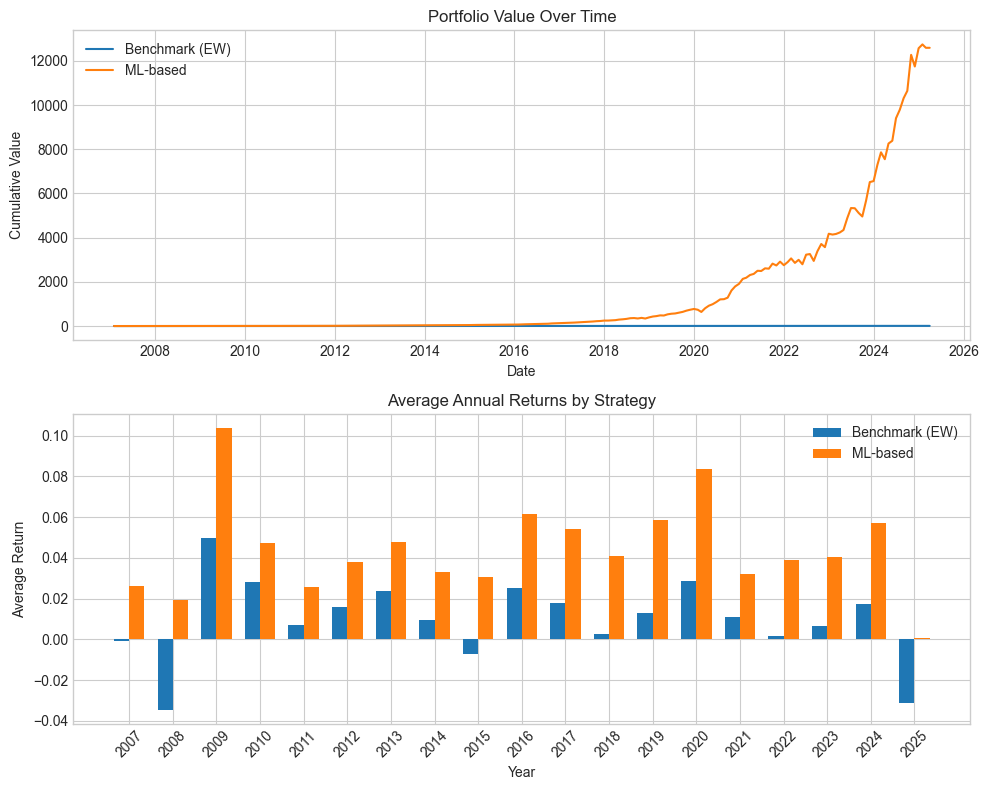

In [10]:
#| label: fig-backtest_perf
#| fig-cap: "Graphical representation of the performance of the portfolios."

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Plot 1: Cumulative returns
cum_ret_benchmark = np.cumprod(1 + portf_returns[:, 0])
cum_ret_ml = np.cumprod(1 + portf_returns[:, 1])

axes[0].plot(t_oos, cum_ret_benchmark, label='Benchmark (EW)', linewidth=1.5)
axes[0].plot(t_oos, cum_ret_ml, label='ML-based', linewidth=1.5)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Cumulative Value')
axes[0].legend()
axes[0].set_title('Portfolio Value Over Time')

# Plot 2: Annual average returns
years = pd.to_datetime(t_oos).year
df_returns = pd.DataFrame({
    'year': years,
    'benchmark': portf_returns[:, 0],
    'ml_based': portf_returns[:, 1]
})
annual_returns = df_returns.groupby('year').mean()

x = np.arange(len(annual_returns))
width = 0.35

axes[1].bar(x - width/2, annual_returns['benchmark'], width, label='Benchmark (EW)')
axes[1].bar(x + width/2, annual_returns['ml_based'], width, label='ML-based')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Return')
axes[1].set_xticks(x)
axes[1].set_xticklabels(annual_returns.index, rotation=45)
axes[1].legend()
axes[1].set_title('Average Annual Returns by Strategy')

plt.tight_layout()
plt.show()

Out of the 12 years of the backtest, the advanced strategy outperforms the benchmark during 10 years. It is less hurtful in two of the four years of aggregate losses (2015 and 2018). This is a satisfactory improvement because the EW benchmark is tough to beat!

## Second example: backtest overfitting

To end this chapter, we quantify the concepts of Section {ref}`#backov`. First, we build a function that is able to generate performance metrics for simple strategies that can be evaluated in batches. The strategies are pure factor bets and depend on three inputs: the chosen characteristic (e.g., market capitalization), a threshold level (quantile of the characteristic) and a direction (long position in the top or bottom of the distribution).

In [11]:
def strat(data, feature, thresh, direction):
    """Compute strategy performance metrics."""
    data_tmp = data[['date', feature, 'R1M']].copy()        # Data
    
    # Investment decision
    data_tmp['decision'] = (direction * data_tmp[feature] > direction * thresh)
    
    # Date-by-date analysis
    result = data_tmp.groupby('date').apply(
        lambda x: pd.Series({
            'nb': x['decision'].sum(),
            'p_return': (x['decision'] / x['decision'].sum() * x['R1M']).sum()
                        if x['decision'].sum() > 0 else 0
        })
    ).reset_index()
    
    # Performance metrics
    avg = result['p_return'].mean()
    sd = result['p_return'].std()
    SR = avg / sd if sd > 0 else 0
    
    return {'avg': avg, 'sd': sd, 'SR': SR}

Then, we test the function on a triplet of arguments. We pick the price-to-book (PB) ratio. The position is positive and the threshold is 0.3, which means that the strategy buys the stocks that have a PB value above the 0.3 quantile of the distribution.

In [12]:
strat(data_ml, 'PB', 0.3, 1)   # Large cap

{'avg': np.float64(0.01229655670147973),
 'sd': np.float64(0.05200102503000609),
 'SR': np.float64(0.23646758298291742)}

The output keeps three quantities that will be useful to compute the statistic {eq}`eq:tSR`. We must now generate these indicators for many strategies. We start by creating the grid of parameters.

In [13]:
feature_list = ["Div_yld", "EPS", "size_avg_252d", "mom_252", "PB", "vol_252"]
thresh_list = np.arange(0.2, 0.85, 0.1)                     # Threshold values
direction_list = [1, -1]                                    # Decision direction

# Create parameter grid
from itertools import product
pars = list(product(feature_list, thresh_list, direction_list))

This makes 84 strategies in total. We can proceed to see how they fare. We plot the corresponding Sharpe ratios below. The top plot shows the strategies that invest in the bottoms of the distributions of characteristics while the bottom plot pertains to the portfolios that are long in the lower parts of these distributions.

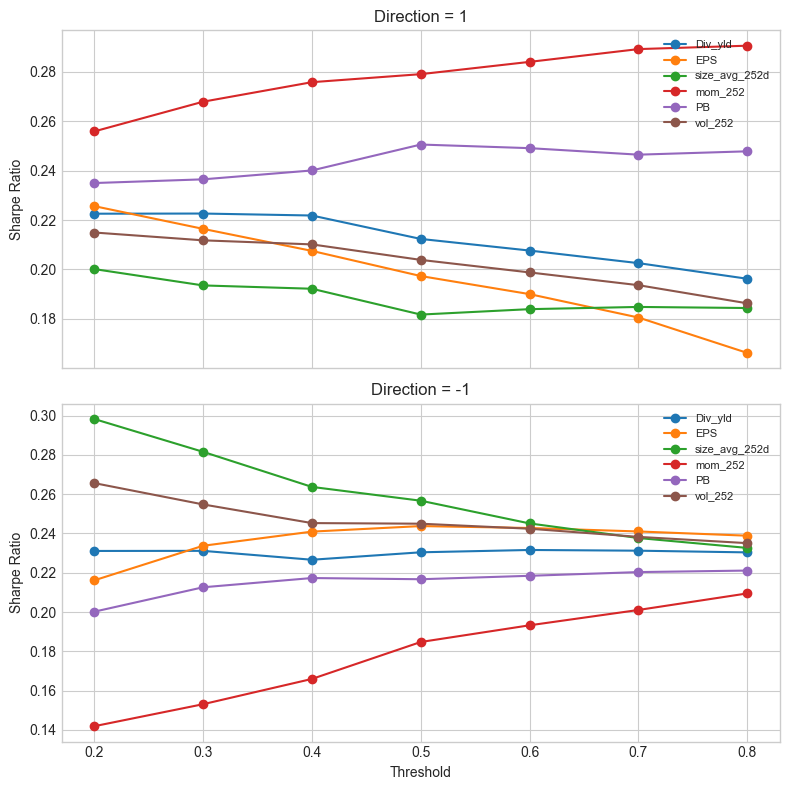

In [14]:
#| label: fig-backov_sr
#| fig-cap: "Sharpe ratios of all backtested strategies."

# Run all strategies
results = []
for feature, thresh, direction in pars:
    res = strat(data_ml, feature, thresh, direction)
    res['feature'] = feature
    res['thresh'] = thresh
    res['direction'] = direction
    results.append(res)

grd = pd.DataFrame(results)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

for direction, ax in zip([1, -1], axes):
    subset = grd[grd['direction'] == direction]
    for feature in feature_list:
        data_feat = subset[subset['feature'] == feature]
        ax.plot(data_feat['thresh'], data_feat['SR'], marker='o', label=feature)
    ax.set_ylabel('Sharpe Ratio')
    ax.set_title(f'Direction = {direction}')
    ax.legend(loc='best', fontsize=8)

axes[1].set_xlabel('Threshold')
plt.tight_layout()
plt.show()

The last step is to compute the statistic {eq}`eq:tSR`. We code it here:

In [15]:
from scipy import stats as sp_stats
from scipy.special import digamma

def DSR(SR, Tt, M, g3, g4, SR_m, SR_v):
    """Compute Deflated Sharpe Ratio statistic."""
    gamma = -digamma(1)                                     # Euler-Mascheroni constant
    SR_star = SR_m + np.sqrt(SR_v) * (
        (1 - gamma) * sp_stats.norm.ppf(1 - 1/M) + 
        gamma * sp_stats.norm.ppf(1 - 1/(M * np.e))
    )                                                       # SR*
    num = (SR - SR_star) * np.sqrt(Tt - 1)                  # Numerator
    den = np.sqrt(1 - g3 * SR + (g4 - 1) / 4 * SR**2)       # Denominator
    return sp_stats.norm.cdf(num / den)

All that remains to do is to evaluate the arguments of the function. The "best" strategy is the one with the highest Sharpe ratio and it is based on market capitalization.

In [16]:
M = len(pars)                                               # Number of strategies we tested
SR = grd['SR'].max()                                        # The SR we want to test
SR_m = grd['SR'].mean()                                     # Average SR across all strategies
SR_v = grd['SR'].var()                                      # Variance of SR

# Find the best strategy
best_idx = grd['SR'].idxmax()
best_feature = grd.loc[best_idx, 'feature']
best_thresh = grd.loc[best_idx, 'thresh']
best_direction = grd.loc[best_idx, 'direction']

print(f"Best strategy: feature={best_feature}, thresh={best_thresh}, direction={best_direction}")

# Compute returns of the best strategy
data_tmp = data_ml[['date', best_feature, 'R1M']].copy()
data_tmp['decision'] = (best_direction * data_tmp[best_feature] > best_direction * best_thresh)

returns_DSR = data_tmp.groupby('date').apply(
    lambda x: (x['decision'] / x['decision'].sum() * x['R1M']).sum()
              if x['decision'].sum() > 0 else 0
)

g3 = sp_stats.skew(returns_DSR)                             # Skewness
g4 = sp_stats.kurtosis(returns_DSR) + 3                     # Kurtosis
Tt = len(returns_DSR)                                       # Number of dates

dsr_value = DSR(SR, Tt, M, g3, g4, SR_m, SR_v)
print(f"Deflated Sharpe Ratio: {dsr_value:.4f}")

Best strategy: feature=size_avg_252d, thresh=0.2, direction=-1
Deflated Sharpe Ratio: 0.4742


The value is not high enough (it does not reach the 90% or 95% threshold) to make the strategy significantly superior to the other ones that were considered in the batch of tests.

## Coding exercises

1. Code the returns of the EW portfolio with pandas functions only (no loop).
2. Code the advanced weighting function defined in Equation {eq}`eq:coqw`.
3. Test it in a small backtest and check its sensitivity to the parameters.
4. Using parallelization (e.g., joblib), avoid the loop in the backtest.